# 문제1

제공된 `pima indians diabetes.csv` 데이터셋은 피마 인디언 여성들의 의료 기록과 당뇨 발병 여부를 포함하고 있습니다. 이 데이터를 활용하여 특정 개인이 당뇨에 걸릴 가능성이 있는지 여부를 예측하는 머신러닝 모델을 구축하는 것이 본 과제의 목표입니다. 데이터 전처리, 모델 설계, 학습, 평가 과정을 거쳐야 하며, 특정 요구사항들을 만족해야 합니다.

### **데이터셋**

[pima indians diabetes.csv](attachment:58270a7d-2565-4d1d-a5ea-7ee0f70fdca4:pima_indians_diabetes.csv)

- `pima indians diabetes.csv`: 의료 기록 (임신 횟수, 혈당 수치, 혈압, 피부 두께, 인슐린 수치, BMI, 당뇨 혈통 기능, 나이) 및 당뇨 발병 여부 (Outcome: 0 또는 1) 포함

분류 모델 구축을 위한 세부 요구사항은 다음과 같습니다.

1-1. 데이터 전처리 및 머신러닝 모델 구축을 분류 문제 해결에 논리적이고 올바른 방법으로 설계하였다. (10점)

1-2. 시험 세트의 정확도가 70% 이상 나올 수 있도록 모델을 설계하였다. (훈련세트와 시험세트의 비율은 8:2로 설정한다.) (10점)

1-3. 아래 속성들을 가진 인물이 당뇨에 걸릴 가능성이 있는지 (당뇨인지, 당뇨가 아닌지) 예측하고, 그 결과를 출력하세요. (5점)

* 임신 횟수: 1
* 혈당 수치: 136
* 혈압: 74
* 피부 두께: 50
* 인슐린 수치: 204
* BMI: 37.4
* 당뇨 혈통 기능: 0.399
* 나이: 24

# 1-1

* 모두 수치형자료로서 스케일링 처리후 데이터 분석을 실시하였습니다. 
* 원본데이터 클래스 비율을 유지하기 위해 stratify = Y로 설정하였습니다. 
* 타겟값이 0과 1로 분류되는 이진형 범주의 데이터로서 로지스틱 회귀도 고려하였으나,
  주변환경의 상호작용을 많이 받는 인체의 데이터로서 주변 데이터를 활용하는 KNN을 활용하여 분석을 실시하였습니다.
* for문을 통하여 최적의 K값을 찾아 재분석하였습니다. 
* 시험데이터의 정확도는 77.9%로서 문제의 요건을 충족하였습니다.
* 예시데이터의 검증을 위해 데이터 역변환 후 해당 샘플을 검증하였습니다. 검증결과 해당 샘플은 당뇨가 아닌 것으로 추정됩니다.

# 1-2

In [101]:
diabetes = pd.read_csv("pima indians diabetes.csv")
diabetes.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [78]:
X = diabetes.drop("Outcome", axis = 1)
Y = diabetes['Outcome']

In [79]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size = 0.2, stratify = Y)

In [86]:
from sklearn.preprocessing import StandardScaler 
ss = StandardScaler()
train_scaled = ss.fit_transform(train_x) 
test_scaled = ss.transform(test_x) 

In [87]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier() 
model.fit(train_scaled, train_y) # model.fit?
model.predict(test_scaled)[:5]

array([1, 0, 1, 0, 0], dtype=int64)

In [88]:
import numpy as np # 행렬로 표현
np.array(test_y)[:5]

array([1, 0, 0, 0, 0], dtype=int64)

In [93]:
model.score(test_scaled, test_y)

0.7792207792207793

In [90]:
box = []
for n in range(1, 31):
    model.n_neighbors = n
    score = model.score(test_scaled, test_y)
    box.append(score)

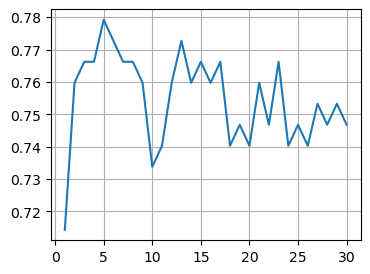

In [91]:
plt.figure(figsize=(4,3))
plt.plot(range(1, 31), box)
plt.grid()
plt.show()

In [92]:
model = KNeighborsClassifier(n_neighbors=5) 
model.fit(train_scaled, train_y) 
model.predict(test_scaled)[:5]

array([1, 0, 1, 0, 0], dtype=int64)

In [94]:
model.score(test_scaled, test_y)

0.7792207792207793

# 1-3

* 임신 횟수: 1
* 혈당 수치: 136
* 혈압: 74
* 피부 두께: 50
* 인슐린 수치: 204
* BMI: 37.4
* 당뇨 혈통 기능: 0.399
* 나이: 24

In [95]:
from sklearn.preprocessing import StandardScaler 

ss = StandardScaler()

In [97]:
diabet_sample = [1, 136, 74, 50, 204, 37.4, 0.399, 24]
diabet_sample = ss.fit_transform([diabet_sample])
diabet_sample

array([[0., 0., 0., 0., 0., 0., 0., 0.]])

In [102]:
model.predict(diabet_sample)

array([0], dtype=int64)

In [103]:
diabet_original = ss.inverse_transform(diabet_sample)
diabet_original

array([[  1.   , 136.   ,  74.   ,  50.   , 204.   ,  37.4  ,   0.399,
         24.   ]])

# 문제2

제공된 `boston_house_prices.csv` 데이터셋은 보스턴 지역 주택의 다양한 속성 및 해당 주택 가격을 포함하고 있습니다. 이 데이터를 활용하여 특정 주택의 가격을 예측하는 머신러닝 모델을 구축하는 것이 본 과제의 목표입니다. 데이터 전처리, 모델 설계, 학습, 평가 과정을 거쳐야 하며, 특정 요구사항들을 만족해야 합니다.

### 데이터셋

[boston_house_prices.csv](attachment:a5233cc0-8cd7-409a-bc1d-6a67a482955d:boston_house_prices.csv)

- `boston_house_prices.csv`: 보스턴 지역 주택 관련 속성 (예: 범죄율, 주택당 평균 방 개수, 접근성 지수 등) 및 주택 가격 (MEDV: 1000 달러 단위의 주택 가격) 포함

회귀 모델 구축을 위한 세부 요구사항은 다음과 같습니다.

2-1. 데이터 전처리 및 머신러닝 모델 구축을 회귀 문제 해결에 논리적이고 올바른 방법으로 설계하였다. (10점)

2-2. 시험 세트에서 모델의 성능 지표인 Mean Absolute Error (MAE)가 3.0 (단위: 1000 달러) 미만으로 나올 수 있도록 모델을 설계하였다. (훈련세트와 시험세트의 비율은 8:2로 설정한다.) (10점)

2-3. 아래 속성을 가진 주택의 가격을 예측하고, 그 결과를 출력하세요. (5점)

* CRIM (지역별 범죄율): 0.02731
* ZN (25,000 평방피트를 초과하는 거주지역 비율): 0.0
* INDUS (비소매 상업지역 비율): 7.07
* CHAS (찰스 강변 위치 변수: 강변이면 1, 아니면 0): 0
* NOX (일산화질소 농도 (10ppm 당)): 0.469
* RM (주택당 평균 방 개수): 6.421
* AGE (1940년 이전에 건축된 소유주택 비율): 78.9
* DIS (5개 보스턴 직업센터까지의 가중 거리): 4.9671
* RAD (방사형 고속도로 접근성 지수): 2.0
* TAX (10,000 달러당 재산세율): 242.0
* PTRATIO (지역별 학생-교사 비율): 17.8
* B (지역별 흑인 거주 비율 (1000(Bk - 0.63)^2), Bk는 흑인 거주 비율): 396.90
* LSTAT (인구 중 하위 계층 비율): 9.14

# 2-1

* 모두 수치형자료로서 스케일링 처리후 데이터 분석을 실시하였습니다. 
* 타겟값은 수치형으로 산출되는 회귀문제로서, 향후 모델의 검증력을 확인하기 위해 선형회귀로 분석하였습니다.
* 분석의 설명력을 강화하기 위해 피처의 중요도를 시각화하였습니다.
* 별도의 데이터엔지니어링 없이 분석결과 문제의 요구조건 충족이 불가하여 PolinomialFeatures를 통해 피처 생성 후 재분석하였습니다.
* 본 테스트의 성능지표인 MAE 기준으로 2.57 산출되어 문제의 조건을 충족하였습니다.
* 분석결과 인구 중 하위 계층의 비율이 가장 주택의 가격에 영향을 많이 미치는 것으로 판단됩니다.
* 중심부까지의 거리와 평균 방갯수도 주택의 가격에 영향을 많이 미치는 변수이나, 분석 전에도 충분히 예상 가능한 내용으로서 유의미한 분석결과는 얻지 못했습니다.
* 예시데이터의 검증을 위해 데이터 역변환 후 해당 샘플을 검증하였습니다. 해당 샘플의 주택가격은 24,700불로 예상됩니다.

# 2-2

In [105]:
# 집값 예측하는 선형 회귀 모델 만들기!
house = pd.read_csv("boston_house_prices.csv")
house.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7


In [106]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [107]:
X = house.drop("MEDV", axis = 1)
Y = house['MEDV']

In [108]:
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size = 0.2) 
# 문제의 요구사항인 훈련세트와 시험세트의 비율은 8:2로 설정

In [109]:
from sklearn.preprocessing import StandardScaler 

ss = StandardScaler()
train_scaled = ss.fit_transform(train_x)
test_scaled = ss.transform(test_x)

In [110]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_scaled, train_y)
model.score(test_scaled, test_y)

0.7494263539777968

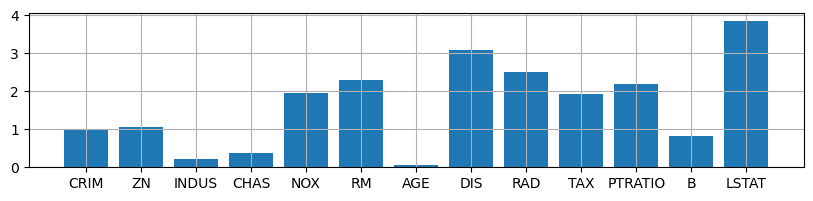

In [111]:
coef = abs(model.coef_) # 기울기가 음수일 수 있으므로
plt.figure(figsize = (10, 2))
plt.bar(X.columns , coef)
plt.grid()
plt.show()

In [112]:
from sklearn.preprocessing import PolynomialFeatures 
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_poly.shape

(506, 104)

In [113]:
train_x, test_x, train_y, test_y = train_test_split(X_poly, Y)

In [114]:
ss = StandardScaler()
train_scaled = ss.fit_transform(train_x)
test_scaled = ss.transform(test_x)

In [115]:
model = LinearRegression()
model.fit(train_scaled, train_y)
model.score(test_scaled, test_y)  # 일반 linear regression의 경우 0.84 정도이므로 성능은 향상되었으나, 과적합 우려 있음. 

0.8151811982634475

In [116]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

# 테스트할 l1_ratio 값 리스트
l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]

# 결과 저장용 리스트
results = []

# 반복 실행
for ratio in l1_ratios:
    model = ElasticNet(alpha=1, l1_ratio=ratio)
    model.fit(train_scaled, train_y)
    score = model.score(test_scaled, test_y)  # R² score
    results.append((ratio, score))
    print(f"l1_ratio={ratio:.2f} → R² score = {score:.4f}")

l1_ratio=0.00 → R² score = 0.6927
l1_ratio=0.25 → R² score = 0.6831
l1_ratio=0.50 → R² score = 0.6806
l1_ratio=0.75 → R² score = 0.6793
l1_ratio=1.00 → R² score = 0.6803


In [117]:
from sklearn.linear_model import Ridge, Lasso

# 집값 예측하는 선형 회귀 모델 만들기!
house = pd.read_csv("boston_house_prices.csv")

X = house.drop("MEDV", axis = 1)
Y = house['MEDV']

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_X = poly.fit_transform(X)

train_x, test_x, train_y, test_y = train_test_split(poly_X, Y)

ss = StandardScaler()
train_scaled = ss.fit_transform(train_x)
test_scaled = ss.transform(test_x)

model = Ridge() # Ridge로 평가시 성능 향상
model.fit(train_scaled, train_y)

print(model.score(train_scaled, train_y))
print(model.score(test_scaled, test_y))

0.9187030433656943
0.8149264637348822


### 회귀 모델의 성능 지표 MAE
* MAE (Mean Absolute Error, 평균 절대 오차): 실제 값과 예측 값 사이의 오차 절댓값들의 평균

In [118]:
pred = model.predict(test_scaled)
pred[:5]

array([34.5312679 , 21.71038465, 18.53267605, 16.46584629, 12.41217753])

In [119]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(test_y, pred)

2.579062909884121

# 2-3

* CRIM (지역별 범죄율): 0.02731
* ZN (25,000 평방피트를 초과하는 거주지역 비율): 0.0
* INDUS (비소매 상업지역 비율): 7.07
* CHAS (찰스 강변 위치 변수: 강변이면 1, 아니면 0): 0
* NOX (일산화질소 농도 (10ppm 당)): 0.469
* RM (주택당 평균 방 개수): 6.421
* AGE (1940년 이전에 건축된 소유주택 비율): 78.9
* DIS (5개 보스턴 직업센터까지의 가중 거리): 4.9671
* RAD (방사형 고속도로 접근성 지수): 2.0
* TAX (10,000 달러당 재산세율): 242.0
* PTRATIO (지역별 학생-교사 비율): 17.8
* B (지역별 흑인 거주 비율 (1000(Bk - 0.63)^2), Bk는 흑인 거주 비율): 396.90
* LSTAT (인구 중 하위 계층 비율): 9.14

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

X = house.drop("MEDV", axis = 1)
Y = house['MEDV']

train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size = 0.2) 

ss = StandardScaler()
train_scaled = ss.fit_transform(train_x)
test_scaled = ss.transform(test_x)

sample = [0.02731, 0.0, 7.07, 0, 0.469, 6.421, 78.9, 4.9671, 2.0, 242.0, 17.8, 396.90, 9.14]
sample = ss.transform([sample])
sample

array([[-0.416287  , -0.50239412, -0.58516098, -0.26761547, -0.74115905,
         0.17380011,  0.35590001,  0.56437745, -0.84749422, -0.97288473,
        -0.26676036,  0.43837795, -0.47252226]])

In [121]:
model = LinearRegression()
model.fit(train_scaled, train_y)
model.score(test_scaled, test_y) 
model.predict(sample)

array([24.74826016])

In [122]:
sample_original = ss.inverse_transform(sample)
sample_original

array([[2.7310e-02, 0.0000e+00, 7.0700e+00, 0.0000e+00, 4.6900e-01,
        6.4210e+00, 7.8900e+01, 4.9671e+00, 2.0000e+00, 2.4200e+02,
        1.7800e+01, 3.9690e+02, 9.1400e+00]])

# 문제3

`bike.csv` 데이터는 특정 시간대의 날씨, 요일, 계절 등 다양한 조건에 따른 공공자전거의 수요(총 대여 건수)를 포함하고 있습니다. 이 데이터를 활용하여 특정 조건에서 공공자전거의 대여 건수를 예측하는 회귀 모델을 구축하는 것이 본 과제의 목표입니다.

### 데이터셋

[bike.csv](attachment:6de680c0-266a-45a1-b144-3c2f0d641f94:bike.csv)

- `bike.csv`: 공공자전거의 시간, 날씨, 계절별 속성 (예: 기온, 습도, 풍속 등) 및 수요 (count: 총 대여 건수) 포함

회귀 모델 구축을 위한 세부 요구사항은 다음과 같습니다.

3-1. 데이터 전처리 및 머신러닝 모델 구축을 회귀 문제 해결에 논리적이고 올바른 방법으로 설계하였다. (15점)

3-2. 시험 세트에서 모델의 성능 지표인 R-Squared의 값이 0.9 이상으로 나올 수 있도록 모델을 설계하였다. (훈련세트와 시험세트의 비율은 8:2로 설정한다.) (15점)

# 3-1

* 모두 수치형자료로서 스케일링 처리후 데이터 분석을 실시하였습니다. 
* 데이터가 시간자료를 포함하고 있고, 데이터분석을 위한 핵심적인 자료로서 해당 시간자료를 연, 월, 일, 시간, 주중여부로 나누어 분석을 실시하였습니다. 
* 회귀분석문제이며, 시간과 관련된 자료로서 별도의 스케일링이 불필요한 트리기반 모델로 분석하였습니다. 
* 본 시험에서 요구한 결정계수의 값이 0.95로서 문제의 조건을 충족하였습니다.
* 분석결과 공공자전거의 수요에 가장 큰 영향을 미치는 요소는 시간적인 요소로 주중일 경우 수요량이 증가하였으며, 시간대별로 수요량의 영향이 크다는 것을 확인하였습니다.

# 3-2

In [1]:
import pandas as pd

bike = pd.read_csv("bike.csv") # datetime 적극 활용
bike.head(3) # season은 봄여름가을겨울, temp와 atemp 는 온도와 체감온도. 

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 0:00,1,0,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 1:00,1,0,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 2:00,1,0,0,1,9.02,13.635,80,0.0,32


In [2]:
bike.info() #datetime은 object 타입이므로 시간데이터로 변경 필요

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   count       10886 non-null  int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 850.6+ KB


In [3]:
bike['datetime'] = pd.to_datetime(bike['datetime'])
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(6)
memory usage: 850.6 KB


In [4]:
bike['datetime'][:3]

0   2011-01-01 00:00:00
1   2011-01-01 01:00:00
2   2011-01-01 02:00:00
Name: datetime, dtype: datetime64[ns]

In [5]:
bike["year"] = bike['datetime'].dt.year
bike["month"] = bike['datetime'].dt.month
bike["day"] = bike['datetime'].dt.day
bike["hour"] = bike['datetime'].dt.hour
bike["weekday"] = bike['datetime'].dt.weekday
bike[:3]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32,2011,1,1,2,5


In [6]:
del bike['datetime']

In [7]:
X = bike.drop('count', axis=1)
Y = bike['count']

In [9]:
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size = 0.2) 
# 문제의 요구사항인 훈련세트와 시험세트의 비율은 8:2로 설정

In [12]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(train_x, train_y)
model.score(test_x, test_y) 

0.9574940800666809

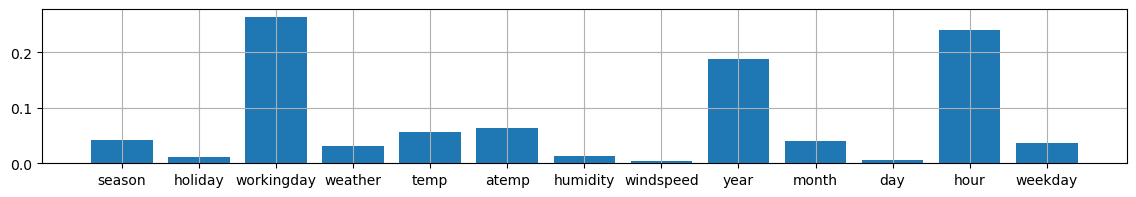

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 2))
plt.bar(X.columns, model.feature_importances_) # 트리기반 모델이므로 feature_importances_ 활용가능
plt.grid()
plt.show()